# Physics examples: composing the layers

The earlier notebooks tour each Phase 2 layer on its own. Here we **compose** them into small models
of a developing cell cluster and watch the emergent behaviour. Nothing new is needed - a simulation
is just a `Model` of steps, and the layers talk to each other through shared **state fields**:

- **`MechanicalRelaxation`** (quasistatic) - packs cells to a force equilibrium under a pair potential.
- **`FreeScreenedDiffusion`** (quasistatic) - a steady morphogen/signal field from per-cell sources.
- **`SaturatingCellGrowth`** (dynamic) - grows each radius toward `max_radius` at a per-cell rate.
- **`Division`** (discrete, stochastic) - volume-conserving, orientable cell division with lineage.

Each macro-step runs a fixed **A -> B -> C** schedule regardless of list order: **A** all quasistatic
steps (in list order), **B** all dynamic steps (accumulated), **C** all discrete steps. So a natural
cell cycle falls out: *sense/relax (A) -> grow (B) -> divide (C)*.

We build four sims:

1. **A proliferation cycle** - grow + relax + divide, with the lineage tree recovered from the run.
2. **Oriented vs isotropic cleavage** - the division axis sets tissue shape.
3. **Contact-inhibited proliferation** - a diffusible signal senses crowding and throttles division.
4. **Flocking** - self-propelled cells align with their neighbours (a Vicsek model).

Then we confirm the whole stack is still differentiable.

In [1]:
import jax
import jax.numpy as jnp

# The library is written for float64; enable it before anything touches JAX.
jax.config.update('jax_enable_x64', True)

import numpy as np
import equinox as eqx
import matplotlib.pyplot as plt

%matplotlib inline

import jax_morph as jxm
from jax_morph.physics import (
    Morse,
    MechanicalRelaxation,
    SaturatingCellGrowth,
    Division,
    DIVISION_RATE,
    FreeScreenedDiffusion,
    reconstruct_lineage,
    ActiveBrownianDynamics2D,
    ACTIVE_HEADING,
)

key = jax.random.PRNGKey(0)
print('jax-morph', jxm.__version__)

jax-morph 0.4.0


A few helpers: seed a live cluster (the library ships no seeding - the initial condition is the
simulation's job), draw circles coloured by a per-cell value, pull a frame out of a `history=True`
trajectory, and measure a cluster's size and anisotropy.

In [2]:
def seed(model, positions, *, capacity, radius=0.5, **cell_fields):
    # Seed the first n slots alive with the given positions/radius; set any extra per-cell fields
    # (a scalar broadcasts to the live cells, an array is written as given).
    positions = jnp.asarray(positions, float)
    n, dim = positions.shape
    s = jxm.build_state_from_model(model).init_empty(capacity=capacity, n_space_dim=dim, n_types=1)
    s = s.update(
        alive=s.alive.at[:n].set(True),
        radius=s.radius.at[:n].set(radius),
        position=s.position.at[:n].set(positions),
        celltype=s.celltype.at[:n, 0].set(1.0),
    )
    for name, val in cell_fields.items():
        s = s.set(name, s[name].at[:n].set(jnp.asarray(val, float)))
    return s


def frame(hist, t):
    # (positions, radii, alive) as numpy arrays for macro-step t of a stacked trajectory.
    return (np.asarray(hist.position[t]), np.asarray(hist.radius[t]), np.asarray(hist.alive[t]))


def frame_state(hist, t):
    return jax.tree_util.tree_map(lambda x: x[t], hist)  # frame t as a full state


def span_limits(hist, pad=0.6):
    # Generous shared limits from the LAST frame's live cells, so a panel series shares one scale.
    pos, rad, alive = frame(hist, -1)
    p = pos[alive.astype(bool)]
    m = float(rad.max()) + pad
    return ((p[:, 0].min() - m, p[:, 0].max() + m), (p[:, 1].min() - m, p[:, 1].max() + m))


def anisotropy(pos, alive):
    # sqrt(lambda_max / lambda_min) of the live-cell position covariance: 1 = round, >1 = elongated.
    p = np.asarray(pos)[np.asarray(alive).astype(bool)]
    w = np.linalg.eigvalsh(np.cov(p.T))
    return float(np.sqrt(w.max() / max(w.min(), 1e-12)))

## 1. A proliferation cycle: grow + relax + divide

The morphogenetic backbone. Three steps compose into a cell cycle:

- `MechanicalRelaxation(Morse(...))` packs the cluster each step (adhesive Morse -> it stays cohesive);
- `SaturatingCellGrowth` grows every radius toward `max_radius` at the per-cell `growth_rate`;
- `Division` splits a cell with probability `1 - exp(-division_rate * dt)`, halving its volume
  (`r -> r * 2**(-1/d)`) into a just-touching daughter.

`growth_rate` and `division_rate` are ordinary **per-cell state fields** set in the initial condition
(and inherited by daughters). A few cells become a packed, growing tissue.

In [3]:
morse = Morse(epsilon=3.0, alpha=2.8)                       # adhesive: a well at contact
prolif = jxm.Model([
    MechanicalRelaxation(morse, max_steps=800, f_tol=1e-3),  # A: pack to equilibrium
    SaturatingCellGrowth(max_radius=0.6),                   # B: grow toward max_radius
    Division(n_space_dim=2),                                # C: isotropic division
])

CAP = 140
p0 = np.array([[0.0, 0.0], [1.0, 0.1], [0.5, 0.9], [-0.4, 0.7]])   # 4 founder cells
s0 = seed(prolif, p0, capacity=CAP, radius=0.5, growth_rate=0.4, division_rate=0.08)

hist = jxm.simulate(prolif, s0, n_steps=40, dt=1.0, key=key, history=True)
counts = np.asarray(hist.alive.sum(axis=1))
print(f'grew {int(s0.alive.sum())} -> {int(counts[-1])} cells; '
      f'division_overflow = {float(hist.division_overflow[-1]):.0f} (0 = capacity never hit)')

grew 4 -> 57 cells; division_overflow = 0 (0 = capacity never hit)


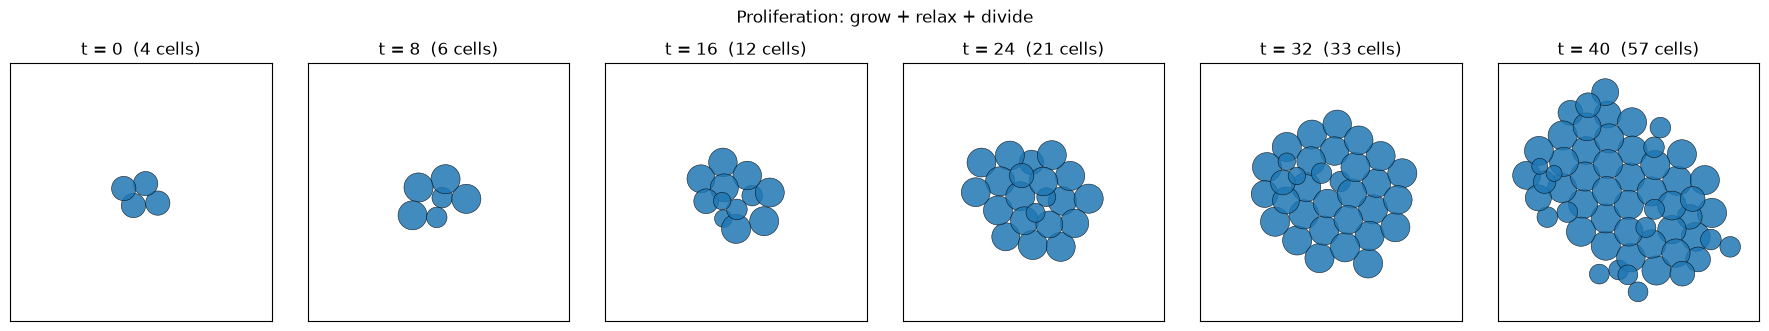

In [4]:
lims = span_limits(hist)
picks = [0, 8, 16, 24, 32, 40]
fig, axes = plt.subplots(1, len(picks), figsize=(3.0 * len(picks), 3.2))
for ax, t in zip(axes, picks):
    st = frame_state(hist, t)
    jxm.viz.draw(st, ax=ax, color='tab:blue', lims=lims,
                 title=f't = {float(hist.t[t]):g}  ({int(st.alive.sum())} cells)')
fig.suptitle('Proliferation: grow + relax + divide', y=1.02)
fig.tight_layout()
plt.show()

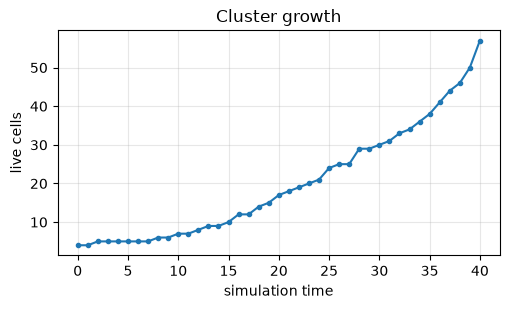

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.plot(np.asarray(hist.t), counts, 'o-', ms=3)  # state tracks physical time t (advanced by dt)
ax.set_xlabel('simulation time')
ax.set_ylabel('live cells')
ax.set_title('Cluster growth')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

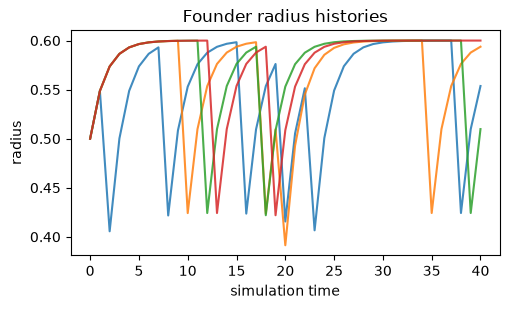

In [6]:
# Per-cell trajectories use reconstructed cell ids, so a storage slot reused after death would never
# join two cells into one trace. Founders 0--3 stay readable in this growing population.
fig, ax = plt.subplots(figsize=(5.2, 3.2))
jxm.viz.plot_timeseries(hist, 'radius', cell_ids=[0, 1, 2, 3], ax=ax, title='Founder radius histories')
fig.tight_layout()
plt.show()

### Lineage

`Division` records `born` (a new-daughter flag) and `mother` (the parent's slot index) every step.
`reconstruct_lineage` walks that complete history and rebuilds the family tree - handling slot
reuse - so a cell's identity is not tied to its array slot. Frame zero supplies the founders. We
colour the final cluster by which of the four founders each cell descends from: the clones are
spatially coherent, as they are in a real growing epithelium.

57 cells ever lived across 4 founding clones


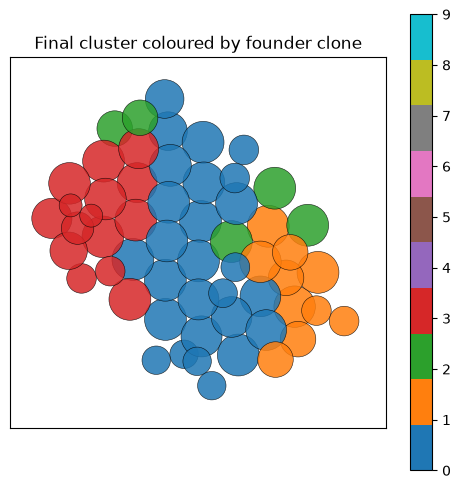

In [7]:
nodes = reconstruct_lineage(hist.born, hist.mother, hist.alive)
by_id = {nd['id']: nd for nd in nodes}


def founder_of(nd):
    while nd['parent'] is not None:
        nd = by_id[nd['parent']]
    return nd['slot']  # the founder's slot (0..3) labels the clone


slot_to_founder = {nd['slot']: founder_of(nd) for nd in nodes}  # last writer per slot = current cell
n_founders = int(s0.alive.sum())
print(f'{len(nodes)} cells ever lived across {n_founders} founding clones')

clone = np.array([slot_to_founder.get(i, -1) for i in range(CAP)], dtype=float)
fig, ax = plt.subplots(figsize=(5.0, 5.0))
jxm.viz.draw(frame_state(hist, -1), ax=ax, color_by=clone, cmap='tab10', vlim=(0, 9), lims=lims,
             title='Final cluster coloured by founder clone')
fig.tight_layout()
plt.show()

## 2. Oriented cleavage sets tissue shape

`Division` places the daughter along `normalize(orientation_snr * axis_hat + noise)`, where
`division_axis` is an optional per-cell direction and `orientation_snr` is the (dimension-independent)
signal-to-noise ratio of that alignment. With `orientation_snr = 0` the split is isotropic; with a
shared axis and a high SNR every division lays its daughter along the same direction and the tissue
**elongates** - the geometry that, in a real embryo, turns a ball of cells into an axis.

A caveat worth seeing: *strong, long-ranged* adhesion makes the cluster behave like a liquid drop that
rounds up whatever the division axis (surface tension erases the anisotropy). So we use a **weak,
short-ranged** `Morse`: a small energy scale (`epsilon = 0.5`) and a **narrow well** (`alpha = 6`) so
the attractive tail dies within about a cell radius of contact - only near-touching cells feel it. We
shorten the range with the well width, not by pulling in the cutoff (a cutoff clamped to the well
would distort the force); the default smooth cutoff then switches off where the energy is already ~0.
That is a loosely cohesive, more solid-like tissue - it holds together but does not flow round - so the
division axis persists as tissue shape. Same grow/relax/divide model twice, changing only the division
orientation.

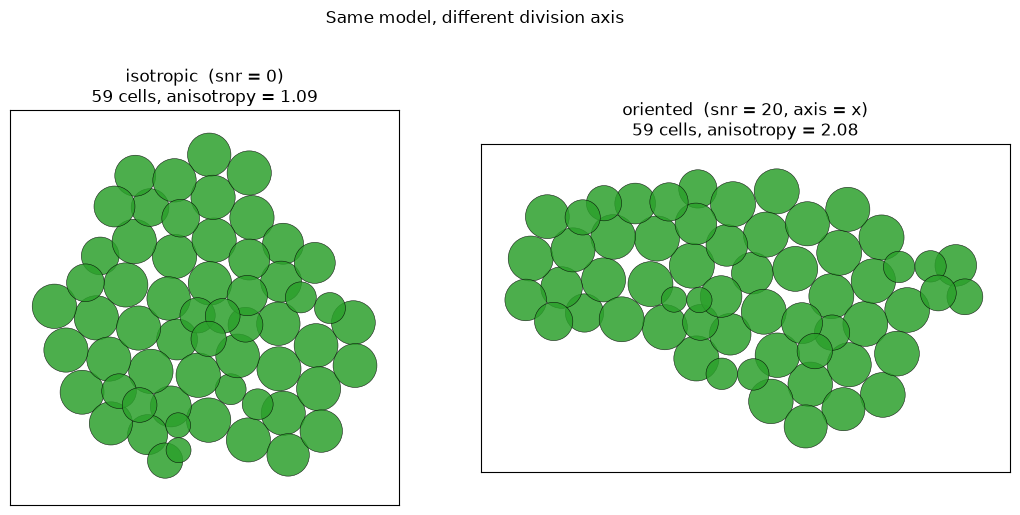

In [8]:
def build(orientation_snr):
    # weak, short-ranged adhesion: small energy (epsilon=0.5) and a narrow well (alpha=6), so the
    # attractive tail dies within ~a cell radius of contact and only near-touching cells interact. The
    # range is set by the well width, not the cutoff (default 1.5-2.5*sigma), which then acts where the
    # Morse energy is already negligible -> a clean force, no cutoff-clamped-at-the-well distortion.
    morse = Morse(epsilon=0.5, alpha=6.0)
    return jxm.Model([
        MechanicalRelaxation(morse, max_steps=800, f_tol=1e-3),
        SaturatingCellGrowth(max_radius=0.6),
        Division(n_space_dim=2, orientation_snr=orientation_snr),
    ])


p_seed = np.array([[0.0, 0.0], [1.0, 0.0]])
axis = np.tile([1.0, 0.0], (len(p_seed), 1))  # heritable polarity along x -> daughters inherit it

runs = {}
for label, snr in [('isotropic  (snr = 0)', 0.0), ('oriented  (snr = 20, axis = x)', 20.0)]:
    model = build(snr)
    s = seed(model, p_seed, capacity=200, radius=0.5,
             growth_rate=0.4, division_rate=0.11, division_axis=axis)
    runs[label] = jxm.simulate(model, s, n_steps=30, dt=1.0, key=jax.random.PRNGKey(1), history=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (label, h) in zip(axes, runs.items()):
    st = frame_state(h, -1)
    pos, _, alive = frame(h, -1)
    jxm.viz.draw(st, ax=ax, color='tab:green', lims=span_limits(h),
                 title=f'{label}\n{int(alive.sum())} cells, anisotropy = {anisotropy(pos, alive):.2f}')
fig.suptitle('Same model, different division axis', y=1.02)
fig.tight_layout()
plt.show()

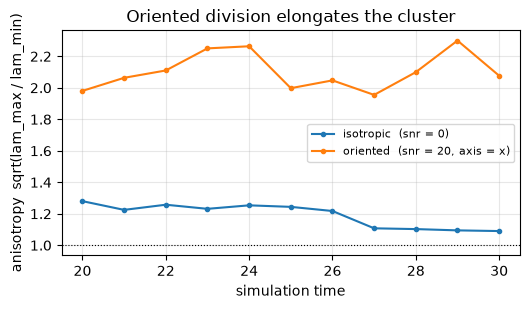

In [9]:
fig, ax = plt.subplots(figsize=(5.4, 3.2))
for label, h in runs.items():
    # a handful of near-collinear cells give a rank-deficient covariance (a meaningless ratio); start
    # the curve once the tissue has real 2-D extent so the anisotropy reflects shape, not conditioning.
    steps = [t for t in range(h.position.shape[0]) if int(h.alive[t].sum()) >= 20]
    aniso = [anisotropy(np.asarray(h.position[t]), np.asarray(h.alive[t])) for t in steps]
    ax.plot(np.asarray(h.t)[steps], aniso, 'o-', ms=3, label=label)
ax.axhline(1.0, color='k', lw=0.8, ls=':')
ax.set_xlabel('simulation time')
ax.set_ylabel('anisotropy  sqrt(lam_max / lam_min)')
ax.set_title('Oriented division elongates the cluster')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Contact-inhibited proliferation: diffusion senses crowding

Now let a **diffusible signal** couple to the division rate. Every cell secretes a signal;
`FreeScreenedDiffusion` sums the steady screened-diffusion field, so a cell's local signal is high
where neighbours are dense. A tiny quasistatic step maps that crowding to a division rate that
*decreases* with it - **contact inhibition of proliferation**. Cells at the crowded interior divide
slowly; cells at the free rim keep proliferating, and the cluster grows from its edge.

This is exactly how layers compose in `jax-morph`: one step writes a field, the next reads it. The
mapping step below is a stand-in for the Phase 3 control layer (a gene network / MLP reading the same
field), which slots in the same way.

In [10]:
class ContactInhibition(jxm.SimulationStep):
    '''Quasistatic: division_rate = base_rate / (1 + sensitivity * local_signal). Reads `chemical`.'''

    step_type = jxm.StepType.QUASISTATIC
    base_rate: float = 0.18
    sensitivity: float = 1.5

    def state_reads(self):
        return (jxm.StateFieldSpec('chemical', shape=(1,), heritable=False),)

    def state_writes(self):
        return (DIVISION_RATE,)

    def __call__(self, state, *, dt, key):
        crowding = state.chemical[:, 0]
        return state.set('division_rate', self.base_rate / (1.0 + self.sensitivity * crowding))


diffusion = FreeScreenedDiffusion(n_field_species=1, n_space_dim=2, diffusion=1.0, degradation=0.6)
inhibit = ContactInhibition(base_rate=0.18, sensitivity=1.5)
tissue = jxm.Model([
    MechanicalRelaxation(Morse(epsilon=3.0, alpha=2.8), max_steps=800, f_tol=1e-3),
    diffusion,
    inhibit,
    SaturatingCellGrowth(max_radius=0.6),
    Division(n_space_dim=2),
])

s0 = seed(tissue, p0, capacity=CAP, radius=0.5, growth_rate=0.4, secretion_rate=1.0)
hist = jxm.simulate(tissue, s0, n_steps=40, dt=1.0, key=key, history=True)
print(f'grew {int(s0.alive.sum())} -> {int(hist.alive[-1].sum())} cells')

def crowding_at(state):
    # The recorded `chemical` is the field BEFORE each step's divisions, so just-born daughters read
    # 0. Recompute it on a frame's cells (positions include the newborns) for an up-to-date map.
    return np.asarray(diffusion(state, dt=1.0, key=None).chemical)[:, 0]

grew 4 -> 53 cells


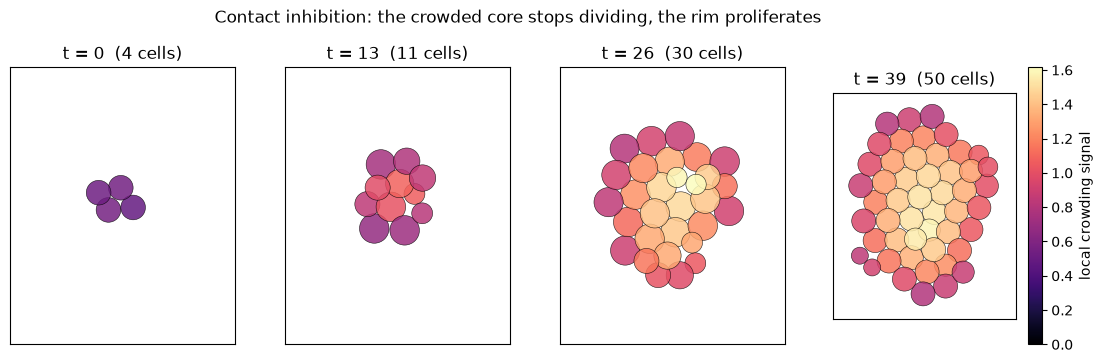

In [11]:
lims = span_limits(hist)
picks = [0, 13, 26, 39]
states = [frame_state(hist, t) for t in picks]
cmax = float(max(crowding_at(st)[np.asarray(st.alive).astype(bool)].max() for st in states))
fig, axes = plt.subplots(1, len(picks), figsize=(3.4 * len(picks), 3.6))
for ax, t, st in zip(axes, picks, states):
    jxm.viz.draw(st, ax=ax, color_by=crowding_at(st), cmap='magma', vlim=(0, cmax), lims=lims,
                 colorbar=ax is axes[-1], title=f't = {float(hist.t[t]):g}  ({int(st.alive.sum())} cells)')
fig.axes[-1].set_ylabel('local crowding signal')
fig.suptitle('Contact inhibition: the crowded core stops dividing, the rim proliferates', y=1.04)
plt.show()

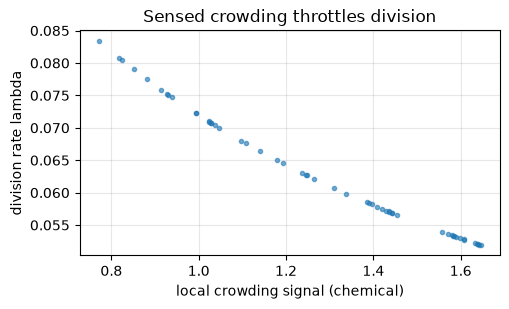

In [12]:
# the emergent rate map: recompute the field and the rate on the final cells (newborns included), so
# every cell shows the up-to-date (crowding -> division rate) relation the model actually applies
final = inhibit(diffusion(frame_state(hist, -1), dt=1.0, key=None), dt=1.0, key=None)
alive = np.asarray(final.alive).astype(bool)
signal = np.asarray(final.chemical)[:, 0][alive]
rate = np.asarray(final.division_rate)[alive]
order = np.argsort(signal)
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.plot(signal[order], rate[order], '.', ms=6, alpha=0.6)
ax.set_xlabel('local crowding signal (chemical)')
ax.set_ylabel('division rate lambda')
ax.set_title('Sensed crowding throttles division')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Flocking: a Vicsek model of self-propelled cells

The last combo shows off `ActiveBrownianDynamics2D` and the reason its heading is a **shared** field.
In the Vicsek model, self-propelled particles turn to align with their neighbours' average heading,
against a rotational noise; below a critical noise they collectively **flock**.

Two composable dynamic steps:

- `ActiveBrownianDynamics2D` self-propels each cell along its heading and diffuses that heading at rate
  `rot_diffusion` (the Vicsek *noise*);
- a small `VicsekAlignment` step reads neighbours' headings and adds an **alignment torque** to the
  same `active_heading` field.

Because dynamic steps accumulate their deltas, the heading update is `dtheta = torque*dt + noise`
without either step knowing about the other - exactly the composition the shared heading was designed
for. We measure the flocking order parameter `phi = |mean_i (cos theta_i, sin theta_i)|` (0 = random,
1 = perfectly aligned) at low vs high noise.

In [13]:
class VicsekAlignment(jxm.SimulationStep):
    # dynamic step: a torque that turns each heading toward its neighbours' mean heading
    step_type = jxm.StepType.DYNAMIC
    strength: float = 2.0   # J: alignment torque strength
    radius: float = 1.0     # interaction radius

    def state_reads(self):
        return (jxm.POSITION, ACTIVE_HEADING)

    def state_writes(self):
        return (ACTIVE_HEADING,)  # a torque delta; accumulates with ABP's rotational-diffusion delta

    def __call__(self, state, *, dt, key):
        theta = state.active_heading
        e = jnp.stack([jnp.cos(theta), jnp.sin(theta)], axis=-1)  # (N, 2) heading unit vectors
        disp = jxm.geometry.pairwise_displacements(state.position, state.displacement)
        r = jxm.ad_utils.safe_norm(disp, axis=-1)  # (N, N) minimum-image distances
        neigh = (r < self.radius) & state.alive[None, :]  # neighbours within radius (self included)
        mean_vec = neigh.astype(e.dtype) @ e  # (N, 2) sum of neighbour heading vectors
        target = jnp.arctan2(mean_vec[:, 1], mean_vec[:, 0])  # local mean heading angle
        dtheta = self.strength * jnp.sin(target - theta) * dt  # restoring torque toward it
        return state.deltas(active_heading=dtheta)


BOX, N = 12.0, 250
space = jxm.geometry.periodic(BOX)


def seed_flock(model, *, v0=0.4, seed=1):
    rng = np.random.default_rng(seed)
    s = jxm.build_state_from_model(model).init_empty(
        capacity=N, n_space_dim=2, n_types=1, space=space
    )
    return s.update(
        alive=s.alive.at[:].set(True),
        radius=s.radius.at[:].set(0.15),
        position=s.position.at[:].set(jnp.asarray(rng.uniform(0.0, BOX, (N, 2)))),
        active_speed=s.active_speed.at[:].set(v0),
        active_heading=s.active_heading.at[:].set(jnp.asarray(rng.uniform(0.0, 2 * np.pi, (N,)))),
    )


def flock(rot_diffusion):
    m = jxm.Model([
        # potential=None -> NoForce: pure Vicsek point particles (self-propulsion + alignment +
        # noise, no interaction force). Any interaction would just be another step.
        ActiveBrownianDynamics2D(None, n_space_dim=2, kT=0.0, rot_diffusion=rot_diffusion),
        VicsekAlignment(strength=2.0, radius=1.0),
    ])
    h = jxm.simulate(m, seed_flock(m), n_steps=80, dt=0.3, key=jax.random.PRNGKey(3), history=True)
    return h


runs = {'low noise  (D_r = 0.05)': flock(0.05), 'high noise  (D_r = 3.0)': flock(3.0)}


def order_parameter(theta):  # |mean of unit heading vectors|; theta shape (..., N)
    return np.abs(np.mean(np.exp(1j * np.asarray(theta)), axis=-1))


for label, h in runs.items():
    print(f'{label}: order phi {order_parameter(h.active_heading[0]):.2f} -> '
          f'{order_parameter(h.active_heading[-1]):.2f}')

low noise  (D_r = 0.05): order phi 0.01 -> 0.79
high noise  (D_r = 3.0): order phi 0.01 -> 0.05


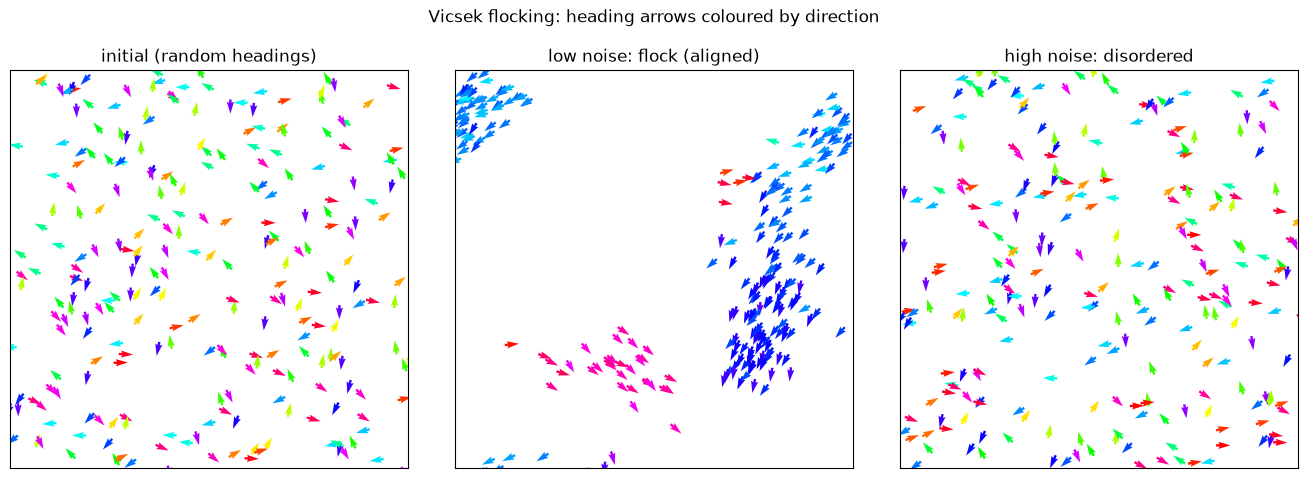

In [14]:
def draw_quiver(ax, pos, theta, title):
    p = np.mod(np.asarray(pos), BOX)  # fold unwrapped coordinates back into the periodic box
    th = np.asarray(theta)
    ax.quiver(p[:, 0], p[:, 1], np.cos(th), np.sin(th), np.mod(th, 2 * np.pi),
              cmap='hsv', clim=(0, 2 * np.pi), scale=28, width=0.006)
    ax.set_xlim(0, BOX)
    ax.set_ylim(0, BOX)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)


low = runs['low noise  (D_r = 0.05)']
high = runs['high noise  (D_r = 3.0)']
panels = [
    (low.position[0], low.active_heading[0], 'initial (random headings)'),
    (low.position[-1], low.active_heading[-1], 'low noise: flock (aligned)'),
    (high.position[-1], high.active_heading[-1], 'high noise: disordered'),
]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, (pos, th, title) in zip(axes, panels):
    draw_quiver(ax, pos, th, title)
fig.suptitle('Vicsek flocking: heading arrows coloured by direction', y=1.03)
fig.tight_layout()
plt.show()

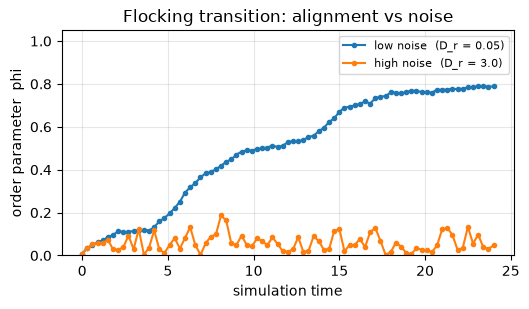

In [15]:
fig, ax = plt.subplots(figsize=(5.4, 3.2))
for label, h in runs.items():
    phi = order_parameter(h.active_heading)  # (n_steps,)
    ax.plot(np.asarray(h.t), phi, 'o-', ms=3, label=label)
ax.set_xlabel('simulation time')
ax.set_ylabel('order parameter  phi')
ax.set_ylim(0, 1.05)
ax.set_title('Flocking transition: alignment vs noise')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## It is all still differentiable

Composition does not cost differentiability. Take the proliferation model and ask how the final
cluster's size depends on the growth rate: differentiate a scalar cluster observable through the whole
scan - relaxation (via implicit-function-theorem equilibrium gradients), growth, and the
straight-through division draws - with `jax.grad`. This is the **pathwise** estimator; for the
discrete division *events* the unbiased route is the score function `trajectory_logp` (the two combine into
the mixed estimator). Here the division decisions do not depend on `growth_rate`, so the pathwise
gradient of cluster size is clean: growing faster makes a bigger cluster.

In [16]:
CAPg = 140
base = seed(prolif, p0, capacity=CAPg, radius=0.5, growth_rate=0.4, division_rate=0.08)


def cluster_size(growth_rate):
    s = base.set('growth_rate', jnp.full((CAPg,), growth_rate))
    final = jxm.simulate(prolif, s, n_steps=30, dt=1.0, key=key)
    a = final.alive.astype(final.position.dtype)
    n = a.sum()
    com = (final.position * a[:, None]).sum(0) / n
    return jnp.sqrt(((((final.position - com) ** 2).sum(-1)) * a).sum() / n)


value, grad = eqx.filter_value_and_grad(cluster_size)(jnp.array(0.4))  # jax scalar -> differentiated
print(f'gyration radius = {float(value):.3f},  d(size)/d(growth_rate) = {float(grad):.3f}')
print('positive: faster growth -> larger cells -> a bigger relaxed cluster')

gyration radius = 2.087,  d(size)/d(growth_rate) = 0.468
positive: faster growth -> larger cells -> a bigger relaxed cluster
